# 定增项目压力测试

## 分析目标
模拟极端市场情景下定增项目的表现，包括：
- 市场危机情景
- 行业利空情景
- 个股重大利空
- 流动性危机情景

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 压力测试模块加载成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 压力测试模块加载成功


In [2]:
from utils.font_manager import init_font, get_font_prop
font_prop = init_font()
fontproperties=font_prop

✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc


## 1. 定义压力测试情景

In [3]:
# ============================================================
# 加载定增分析配置（使用真实数据）
# ============================================================
from utils.config_loader import load_placement_config, print_config_summary

# 加载配置（自动尝试使用真实市场数据）
print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 创建分析器
from utils.analysis_tools import PrivatePlacementRiskAnalyzer
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

# ============================================================
# 压力测试情景
# ============================================================
stress_scenarios = {
    '市场危机_2008': {
        'description': '模拟2008年金融危机，股价下跌60%',
        'price_drop': 0.60,
        'volatility_spike': 2.0,
        'liquidity_crunch': True
    },
    '市场危机_2020': {
        'description': '模拟2020年疫情，股价下跌40%',
        'price_drop': 0.40,
        'volatility_spike': 1.5,
        'liquidity_crunch': False
    },
    '行业政策收紧': {
        'description': '行业监管政策收紧，股价下跌25%',
        'price_drop': 0.25,
        'volatility_spike': 1.2,
        'liquidity_crunch': False
    },
    '个股重大利空': {
        'description': '公司业绩暴雷，股价下跌35%',
        'price_drop': 0.35,
        'volatility_spike': 1.8,
        'liquidity_crunch': False
    },
    '流动性危机': {
        'description': '市场流动性枯竭，股价下跌20%并波动率飙升',
        'price_drop': 0.20,
        'volatility_spike': 2.5,
        'liquidity_crunch': True
    },
    '极端熊市': {
        'description': '极端熊市情景，股价下跌50%',
        'price_drop': 0.50,
        'volatility_spike': 1.3,
        'liquidity_crunch': True
    }
}

print('\n=== 压力测试情景 ===')
for name, params in stress_scenarios.items():
    print(f"\n{name}:")
    print(f"  {params['description']}")
    print(f"  股价跌幅: {params['price_drop']*100:.0f}%")
    print(f"  波动率倍数: {params['volatility_spike']}x")

正在加载配置...
✅ 已加载定增参数: ../300735_SZ_placement_params.json
✅ 已加载市场数据: ../300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%

=== 压力测试情景 ===

市场危机_2008:
  模拟2008年金融危机，股价下跌60%
  股价跌幅: 60%
  波动率倍数: 2.0x

市场危机_2020:
  模拟2020年疫情，股价下跌40%
  股价跌幅: 40%
  波动率倍数: 1.5x

行业政策收紧:
  行业监管政策收紧，股价下跌25%
  股价跌幅: 25%
  波动率倍数: 1.2x

个股重大利空:
  公司业绩暴雷，股价下跌35%
  股价跌幅: 35%
  波动率倍数: 1.8x

流动性危机:
  市场流动性枯竭，股价下跌20%并波动率飙升
  股价跌幅: 20%
  波动率倍数: 2.5x

极端熊市:
  极端熊市情景，股价下跌50%
  股价跌幅: 50%
  波动率倍数: 1.3x


## 2. 执行压力测试


=== 压力测试结果 ===
 scenario  stressed_price           pnl  pnl_percent  break_even_distance
市场危机_2008           9.552 -5.346533e+07   -52.818135             1.321750
市场危机_2020          14.328 -2.958533e+07   -29.227203             0.547834
   行业政策收紧          17.910 -1.167533e+07   -11.534003             0.238267
   个股重大利空          15.522 -2.361533e+07   -23.329470             0.428769
    流动性危机          19.104 -5.705333e+06    -5.636270             0.160875
     极端熊市          11.940 -4.152533e+07   -41.022669             0.857400


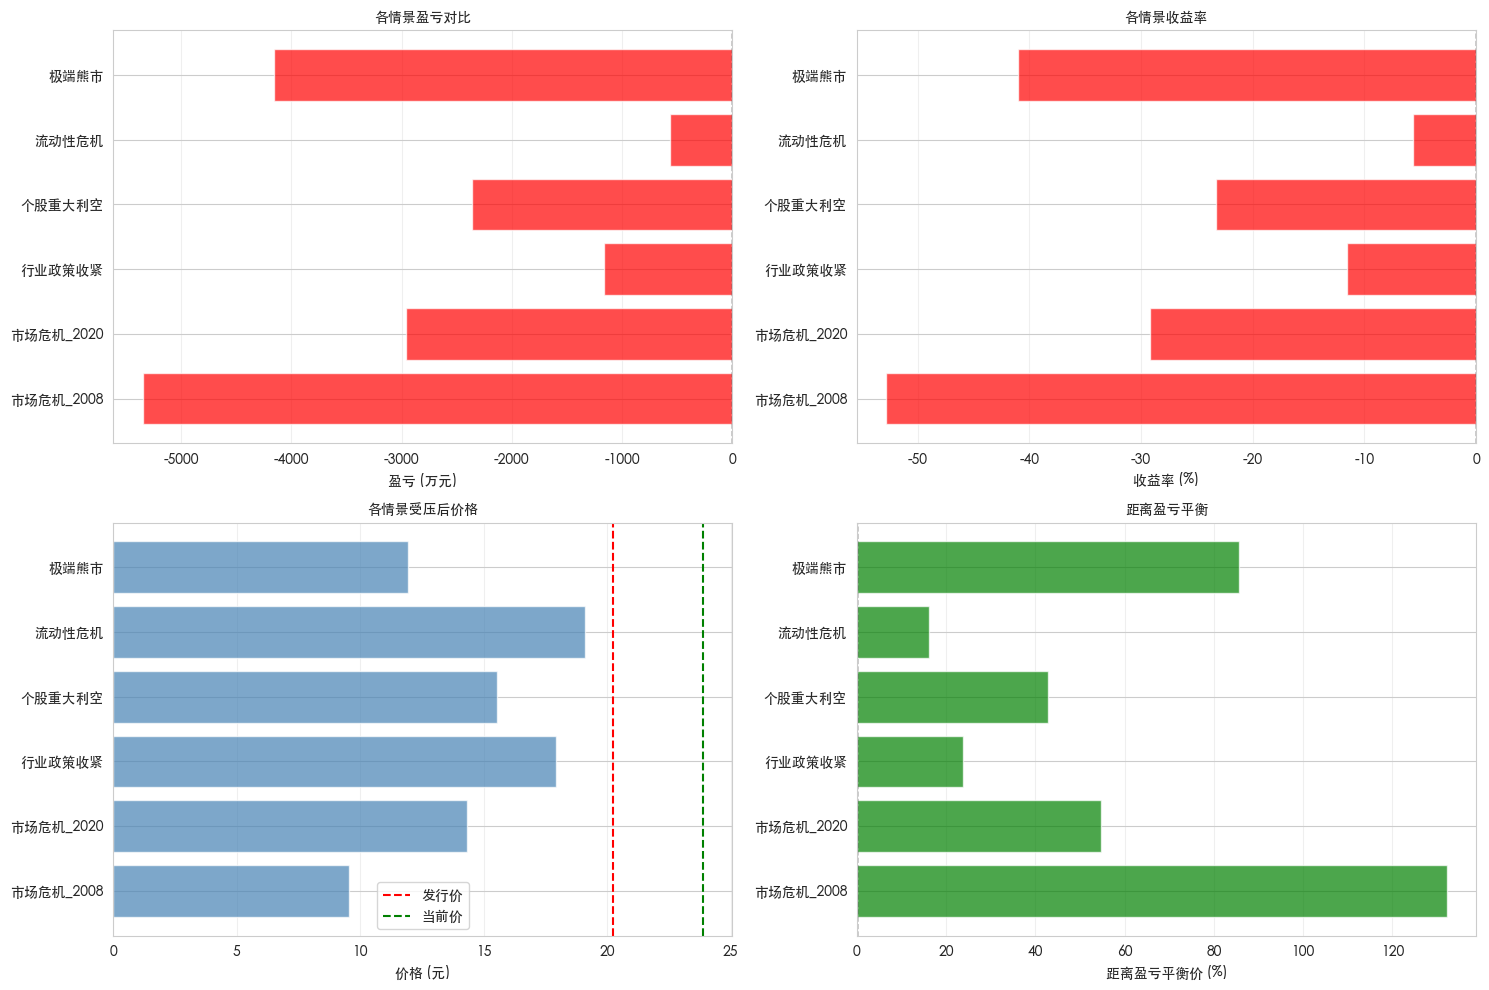

In [4]:
# 运行压力测试
stress_results = analyzer.stress_test(stress_scenarios)

print('\n=== 压力测试结果 ===')
print(stress_results.to_string(index=False))

# 可视化
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. 各情景盈亏
colors = ['green' if r > 0 else 'red' for r in stress_results['pnl']]
ax1.barh(stress_results['scenario'], stress_results['pnl']/10000, color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('盈亏 (万元)', fontproperties=font_prop)
ax1.set_title('各情景盈亏对比', fontproperties=font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, axis='x', alpha=0.3)

# 2. 各情景收益率
bars = ax2.barh(stress_results['scenario'], stress_results['pnl_percent'], color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('收益率 (%)', fontproperties=font_prop)
ax2.set_title('各情景收益率', fontproperties=font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, axis='x', alpha=0.3)

# 3. 受压价格
ax3.barh(stress_results['scenario'], stress_results['stressed_price'], color='steelblue', alpha=0.7)
ax3.axvline(x=analyzer.issue_price, color='r', linestyle='--', label='发行价')
ax3.axvline(x=analyzer.current_price, color='g', linestyle='--', label='当前价')
ax3.set_xlabel('价格 (元)', fontproperties=font_prop)
ax3.set_title('各情景受压后价格', fontproperties=font_prop)
ax3.legend(prop=font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
ax3.grid(True, axis='x', alpha=0.3)

# 4. 距离盈亏平衡
ax4.barh(stress_results['scenario'], stress_results['break_even_distance']*100, 
        color=['green' if x > 0 else 'red' for x in stress_results['break_even_distance']], alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('距离盈亏平衡价 (%)', fontproperties=font_prop)
ax4.set_title('距离盈亏平衡', fontproperties=font_prop)
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax4.get_xticklabels():
    label.set_fontproperties(font_prop)
ax4.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 极端情景分析

In [5]:
# 分析最坏情景
worst_case = stress_results.loc[stress_results['pnl'].idxmin()]

print('\n=== 最坏情景分析 ===')
print(f"\n最坏情景: {worst_case['scenario']}")
print(f"  描述: {stress_scenarios[worst_case['scenario']]['description']}")
print(f"  受压后价格: {worst_case['stressed_price']:.2f} 元/股")
print(f"  亏损金额: {abs(worst_case['pnl'])/10000:.2f} 万元")
print(f"  亏损率: {worst_case['pnl_percent']:.2f}%")

# 计算回本需要的涨幅
recovery_needed = (analyzer.issue_price - worst_case['stressed_price']) / worst_case['stressed_price'] * 100
print(f"  回本需要涨幅: {recovery_needed:.1f}%")

# 恢复时间估算（假设年化增长率）
recovery_rates = [0.20, 0.30, 0.50]  # 20%, 30%, 50%年化
for rate in recovery_rates:
    years = np.log(analyzer.issue_price / worst_case['stressed_price']) / np.log(1 + rate)
    print(f"  年化{rate*100:.0f}%涨幅下恢复需{years:.1f}年")


=== 最坏情景分析 ===

最坏情景: 市场危机_2008
  描述: 模拟2008年金融危机，股价下跌60%
  受压后价格: 9.55 元/股
  亏损金额: 5346.53 万元
  亏损率: -52.82%
  回本需要涨幅: 111.9%
  年化20%涨幅下恢复需4.1年
  年化30%涨幅下恢复需2.9年
  年化50%涨幅下恢复需1.9年


## 4. 压力测试结论

In [6]:
# 统计盈利情景数量
profit_scenarios = (stress_results['pnl'] > 0).sum()
total_scenarios = len(stress_results)

print('\n' + '='*60)
print('压力测试结论')
print('='*60)

print(f"\n📊 压力情景统计:")
print(f"   总情景数: {total_scenarios}")
print(f"   盈利情景: {profit_scenarios}")
print(f"   亏损情景: {total_scenarios - profit_scenarios}")
print(f"   盈利概率: {profit_scenarios/total_scenarios*100:.1f}%")

print(f"\n⚠️ 风险提示:")
worst_loss = stress_results['pnl'].min() / 10000
print(f"   最大潜在亏损: {abs(worst_loss):.2f} 万元")
print(f"   最大亏损率: {stress_results['pnl_percent'].min():.2f}%")

# 风险等级
if profit_scenarios >= total_scenarios * 0.7:
    risk_level = "低风险 - 大部分情景下盈利"
    color = "🟢"
elif profit_scenarios >= total_scenarios * 0.4:
    risk_level = "中等风险 - 约一半情景下盈利"
    color = "🟡"
else:
    risk_level = "高风险 - 大部分情景下亏损"
    color = "🔴"

print(f"\n{color} 压力测试评级: {risk_level}")

print("\n💡 应对建议:")
if profit_scenarios < total_scenarios * 0.5:
    print("  ⚠️  项目抗风险能力较弱，建议:")
    print("     1. 考虑降低投资仓位")
    print("     2. 设置止损线")
    print("     3. 分批建仓")
else:
    print("  ✅  项目抗风险能力尚可，但仍需:")
    print("     1. 密切关注市场动态")
    print("     2. 控制投资仓位")
    print("     3. 做好对冲准备")


压力测试结论

📊 压力情景统计:
   总情景数: 6
   盈利情景: 0
   亏损情景: 6
   盈利概率: 0.0%

⚠️ 风险提示:
   最大潜在亏损: 5346.53 万元
   最大亏损率: -52.82%

🔴 压力测试评级: 高风险 - 大部分情景下亏损

💡 应对建议:
  ⚠️  项目抗风险能力较弱，建议:
     1. 考虑降低投资仓位
     2. 设置止损线
     3. 分批建仓
